# 5 &middot; Solving the Minimization: Newton vs. Gradient Descent

Time to open the solver box. We pin a beam's left edge, grab its **whole right
edge** as a handle, fix a target down-and-to-the-right, and drive the beam to
equilibrium from rest with two methods:

* **Gradient descent** &mdash; step along \(-\nabla E\).
* **Newton** &mdash; step along \(-H^{-1}\nabla E\), using curvature.

Per iteration we track the energy, the gradient norm \(\lVert\nabla E\rVert\),
and the **Newton decrement** \(\lambda = \sqrt{\nabla E^\top H^{-1}\nabla E}\).

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
import simkit.energies as energies
from simkit.solvers import newton_solver
import utils
os.makedirs("media", exist_ok=True)

## The objective

Elastic + pinned-left-edge + right-edge handle, all stable Neo-Hookean. We keep
the **handle spring soft** (similar magnitude to the elastic forces) so the
problem is not horribly ill-conditioned &mdash; otherwise gradient descent just
yanks the handle and leaves the rest of the beam untouched. The
`energy / gradient / hessian` read like the math; `quad` is the spring penalty
\(\tfrac12 x^\top Q x + b^\top x\).

In [2]:
X, T = utils.triangulated_grid(nx=12, ny=4, width=2.0, height=0.4)
n, dim = X.shape
J, vol = simkit.deformation_jacobian(X, T), simkit.volume(X, T)
mu, lam = simkit.ympr_to_lame(0.5, 0.45)                       # soft beam
mu  = np.full((len(T), 1), mu)
lam = np.full((len(T), 1), lam)

pin_idx   = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
right_idx = np.where(X[:, 0] >= X[:, 0].max() - 1e-6)[0]
Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, 1e2)   # gentle pin
targets = X[right_idx] + np.array([0.5, -0.7])                 # pull down-and-right
Q_h, b_h = simkit.dirichlet_penalty(right_idx, targets, n, 25.0)       # soft handle

def quad(Q, b, xc):  return 0.5 * (xc.T @ (Q @ xc))[0, 0] + (b.T @ xc)[0, 0]

def energy(x):
    xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
    E_elastic = energies.macklin_mueller_neo_hookean_energy_x(xn, J, mu, lam, vol)
    E_pin     = quad(Q_pin, b_pin, xc)
    E_handle  = quad(Q_h, b_h, xc)
    E_total   = E_elastic + E_pin + E_handle
    return E_total
def gradient(x):
    xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
    g_elastic = energies.macklin_mueller_neo_hookean_gradient_x(xn, J, mu, lam, vol)
    g_pin     = Q_pin @ xc + b_pin
    g_handle  = Q_h @ xc + b_h
    g_total   = g_elastic + g_pin + g_handle
    return g_total
def hessian(x):
    xn = x.reshape(-1, dim)
    H_elastic = energies.macklin_mueller_neo_hookean_hessian_x(xn, J, mu, lam, vol, psd=True)
    H_pin     = Q_pin
    H_handle  = Q_h
    H_total   = H_elastic + H_pin + H_handle
    return H_total

## The two solver loops

They differ only in the **search direction**. Both use a backtracking line
search (tutorial 6). Each records per-iteration metrics and the deformed state.

In [3]:
def run_solver(direction, n_iters=60):
    """direction(g, H) -> step. Returns (states, metrics)."""
    x = X.flatten().reshape(-1, 1).copy()
    states, E, G, DEC = [x.reshape(n, dim).copy()], [], [], []
    for _ in range(n_iters):
        g, H = gradient(x), hessian(x)
        dx = direction(g, H)
        dec = float(np.sqrt(max(-(g.T @ dx)[0, 0], 0.0)))     # sqrt(g^T H^-1 g) for Newton
        alpha, _, _ = simkit.backtracking_line_search(energy, x, g, dx)
        x = x + alpha * dx
        E.append(energy(x)); G.append(float(np.linalg.norm(g))); DEC.append(dec)
        states.append(x.reshape(n, dim).copy())
        if np.linalg.norm(alpha * dx) < 1e-9:
            break
    return states, {"energy": E, "grad": G, "decrement": DEC}

newton_dir = lambda g, H: sp.sparse.linalg.spsolve(H.tocsc(), -g).reshape(-1, 1)
gd_dir     = lambda g, H: -g.reshape(-1, 1)

newton_states, newton_metrics = run_solver(newton_dir)
gd_states,     gd_metrics     = run_solver(gd_dir)
print(f"Newton:           {len(newton_metrics['energy'])} iters, final |grad| = {newton_metrics['grad'][-1]:.2e}")
print(f"Gradient Descent: {len(gd_metrics['energy'])} iters, final |grad| = {gd_metrics['grad'][-1]:.2e}")

Newton:           11 iters, final |grad| = 2.57e-11
Gradient Descent: 60 iters, final |grad| = 2.01e-01


## Convergence curves

Newton's quadratic convergence crushes the gradient norm in a handful of steps;
gradient descent crawls on the stiff, ill-conditioned elastic Hessian. (GD never
forms \(H\), so it has no Newton decrement.)

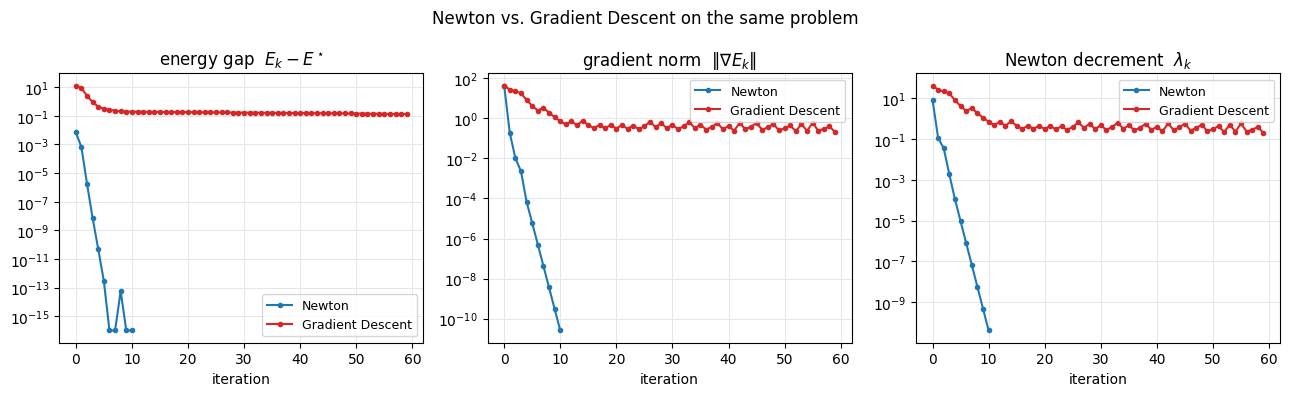

In [4]:
fig, _ = utils.convergence_plot(
    {"Newton": newton_metrics, "Gradient Descent": gd_metrics},
    title="Newton vs. Gradient Descent on the same problem")
plt.show()

## Watching the beam converge (one frame per iteration)


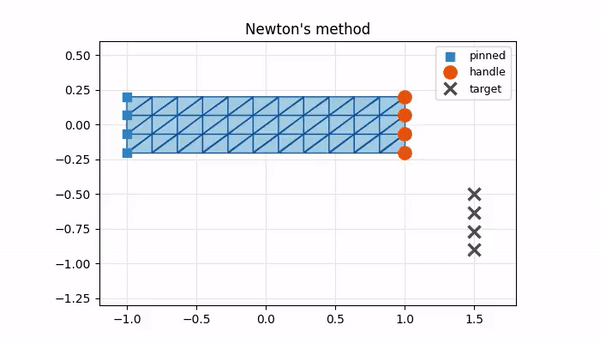

In [5]:
lims = ((-1.2, 1.8), (-1.3, 0.6))
for name, states, fps in [("newton", newton_states, 6), ("gradient_descent", gd_states, 10)]:
    fig, anim = utils.animate_mesh(states, T, lims=lims, title=name.replace("_", " ").title(),
        pin_pts=X[pin_idx], handle_traj=[s[right_idx] for s in states],
        target_pts=[targets] * len(states), fps=fps)
    utils.save_anim(anim, f"media/05_{name}.mp4", fps=fps)
    plt.close(fig)
display_newton = utils.animate_mesh(newton_states, T, lims=lims, title="Newton's method",
    pin_pts=X[pin_idx], handle_traj=[s[right_idx] for s in newton_states],
    target_pts=[targets] * len(newton_states), fps=6)
plt.close(display_newton[0])
utils.show_anim(display_newton[1])


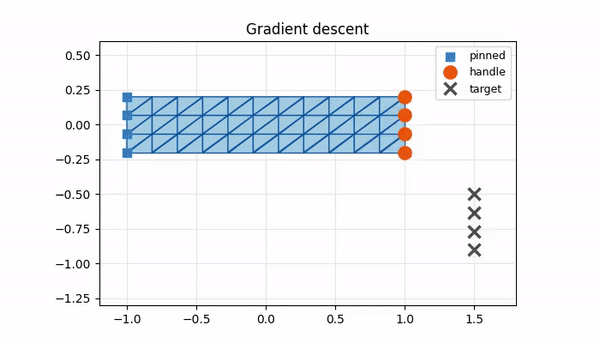

In [6]:
gd_anim = utils.animate_mesh(gd_states, T, lims=lims, title="Gradient descent",
    pin_pts=X[pin_idx], handle_traj=[s[right_idx] for s in gd_states],
    target_pts=[targets] * len(gd_states), fps=10)
plt.close(gd_anim[0])
utils.show_anim(gd_anim[1])

### Takeaways
* **Newton** uses curvature and converges *quadratically* &mdash; ideal for stiff
  elasticity.
* **Gradient descent** ignores curvature and stalls.
* The **Newton decrement** is a clean, scale-aware stopping measure.

But the Newton *step length* needs care &mdash; that's tutorial 6.